# CNNs y Conexiones Residuales

## Actividad 1: Implementación de ResNet18

Implementamos ResNet18 usando PyTorch. La red consta de un *stem* inicial (conv + bn + relu), 4 *stages* con 2 bloques residuales cada uno (2,2,2,2 → total 8 bloques × 2 convs = 16 capas + conv inicial + fc = 18 capas), y un clasificador final.

Dado que entrenaremos en **CIFAR-100** (imágenes de 32×32), adaptamos el *stem* original de ResNet (diseñado para ImageNet de 224×224) usando un kernel 3×3 con stride 1 y eliminando el maxpool inicial, lo cual es estándar para CIFAR.

In [1]:
# Importar librerias necesarias
import torch
import torch.nn as nn
import torch.nn.functional as F

import torchvision
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np
import time

torch.manual_seed(42)
np.random.seed(42)

In [29]:
# bloque basico

class BasicBlock(nn.Module):
    expansion = 1  

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        # Primera convolución 3x3 + batchnorm
        self.conv1 = nn.Conv2d(in_channels, out_channels,
                               kernel_size=3, stride=stride,
                               padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        # Segunda convolución 3x3 + batchnorm
        self.conv2 = nn.Conv2d(out_channels, out_channels,
                               kernel_size=3, stride=1,
                               padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Shortcut: identidad si las dimensiones coinciden,
        # proyección 1x1 si cambia el número de canales o el stride
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels * self.expansion:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels * self.expansion,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * self.expansion)
            )

    def forward(self, x):
        identity = x

        # conv1 -> bn -> relu
        out = F.relu(self.bn1(self.conv1(x)))

        # conv2 -> bn
        out = self.bn2(self.conv2(out))

        # Sumar shortcut (conexión residual)
        out = out + self.shortcut(identity)

        # Activación final
        out = F.relu(out)

        return out

# ResNet
class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes=100):
        super().__init__()

        self.in_channels = 64

        # Stem adaptado para CIFAR (imágenes 32x32)
        # Usamos kernel 3x3, stride 1, sin maxpool para no reducir demasiado
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1,
                               padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        self.maxpool = nn.Identity()

        self.layer1 = self._make_layer(block, 64,  layers[0], stride=1)
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        # Pooling global adaptativo y capa densa de clasificación
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, blocks, stride):
        layers = []

        layers.append(block(self.in_channels, out_channels, stride))

        self.in_channels = out_channels * block.expansion

        for _ in range(1, blocks):
            layers.append(block(self.in_channels, out_channels, stride=1))

        return nn.Sequential(*layers)

    def forward(self, x):
        # Forward del stem inicial
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x


# constructor ResNet18
def ResNet18(num_classes=100):
    return ResNet(BasicBlock, [2, 2, 2, 2], num_classes=num_classes)


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


## Actividad 2: Variante sin conexiones residuales

Definimos una variante de ResNet18 **sin** conexiones residuales (*PlainNet*). Mantenemos exactamente la misma arquitectura: mismas convoluciones, mismos BatchNorm, mismas activaciones y el mismo número de parámetros entrenables (salvo los *shortcuts* de proyección 1×1, que aquí no existen). La única diferencia es que eliminamos el `+ identity` en el forward del bloque.

In [3]:
# bloque plano (sin conex.resid.)
class PlainBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels,
                               kernel_size=3, stride=stride,
                               padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels,
                               kernel_size=3, stride=1,
                               padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # NO hay conexión residual

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = F.relu(out)
        return out


def PlainNet18(num_classes=100):
    return ResNet(PlainBlock, [2, 2, 2, 2], num_classes=num_classes)

_resnet = ResNet18(num_classes=100)
_plainnet = PlainNet18(num_classes=100)
print('Parámetros ResNet18:  ', sum(p.numel() for p in _resnet.parameters()))
print('Parámetros PlainNet18:', sum(p.numel() for p in _plainnet.parameters()))

Parámetros ResNet18:   11220132
Parámetros PlainNet18: 11046308


In [6]:
# Transformaciones

mean = (0.5071, 0.4867, 0.4408)
std = (0.2675, 0.2565, 0.2761)

transform_train = transforms.Compose([

    transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
    transforms.ToTensor(),

    transforms.Normalize(mean, std),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])


# Cargamos el dataset

train_dataset = torchvision.datasets.CIFAR100(
    root='./data', train=True, download=True, transform=transform_train
)

test_dataset = torchvision.datasets.CIFAR100(
    root='./data', train=False, download=True, transform=transform_test
)

batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size,
                          shuffle=True, num_workers=2, pin_memory=True)

test_loader  = DataLoader(test_dataset, batch_size=batch_size,
                          shuffle=False, num_workers=2, pin_memory=True)

# modelos, optimizador y perdida 

model_resnet = ResNet18(num_classes=100).to(device)
model_plain  = PlainNet18(num_classes=100).to(device)

criterion = nn.CrossEntropyLoss()
lr = 1e-2

optimizer_resnet = optim.SGD(model_resnet.parameters(), lr=lr, momentum=0.9,weight_decay=5e-4)
optimizer_plain = optim.SGD(model_plain.parameters(), lr=lr, momentum=0.9,weight_decay=5e-4)

num_epochs = 50
scheduler_resnet = optim.lr_scheduler.CosineAnnealingLR(optimizer_resnet, T_max=num_epochs)
scheduler_plain  = optim.lr_scheduler.CosineAnnealingLR(optimizer_plain,  T_max=num_epochs)

model = model_resnet
optimizer = optimizer_resnet

100%|██████████| 169M/169M [00:05<00:00, 29.0MB/s] 


Device: cuda


In [7]:
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


In [8]:
# entrenamiento

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

      
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    accuracy = 100.0 * correct / total

    return epoch_loss, accuracy


def evaluate(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    accuracy = 100.0 * correct / total

    return epoch_loss, accuracy

In [9]:
def train_model(model, optimizer, scheduler, num_epochs, train_loader, test_loader,
                criterion, device, name='model'):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    print(f'\n=== Entrenando {name} ===')
    t0 = time.time()

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss,   val_acc   = evaluate(model, test_loader, criterion, device)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f'[{name}] Epoch {epoch+1:02d}/{num_epochs} | '
              f'train_loss={train_loss:.4f} train_acc={train_acc:.2f}% | '
              f'val_loss={val_loss:.4f} val_acc={val_acc:.2f}%')

    print(f'Tiempo total {name}: {(time.time()-t0)/60:.1f} min')
    return history

In [10]:
history_resnet = train_model(model_resnet, optimizer_resnet, scheduler_resnet,
                             num_epochs, train_loader, test_loader,
                             criterion, device, name='ResNet18')


=== Entrenando ResNet18 ===
[ResNet18] Epoch 01/50 | train_loss=3.6916 train_acc=13.59% | val_loss=3.3080 val_acc=20.63%
[ResNet18] Epoch 02/50 | train_loss=2.9576 train_acc=25.91% | val_loss=2.7267 val_acc=31.45%
[ResNet18] Epoch 03/50 | train_loss=2.5124 train_acc=34.65% | val_loss=2.4780 val_acc=36.04%
[ResNet18] Epoch 04/50 | train_loss=2.2030 train_acc=41.15% | val_loss=2.2605 val_acc=41.40%
[ResNet18] Epoch 05/50 | train_loss=1.9809 train_acc=46.19% | val_loss=2.1340 val_acc=44.83%
[ResNet18] Epoch 06/50 | train_loss=1.8039 train_acc=50.14% | val_loss=1.9854 val_acc=46.87%
[ResNet18] Epoch 07/50 | train_loss=1.6770 train_acc=53.28% | val_loss=1.7484 val_acc=52.22%
[ResNet18] Epoch 08/50 | train_loss=1.5584 train_acc=55.87% | val_loss=1.8102 val_acc=52.01%
[ResNet18] Epoch 09/50 | train_loss=1.4567 train_acc=58.45% | val_loss=1.6202 val_acc=55.45%
[ResNet18] Epoch 10/50 | train_loss=1.3816 train_acc=60.48% | val_loss=1.7725 val_acc=53.32%
[ResNet18] Epoch 11/50 | train_loss=1.296

In [11]:
history_plain  = train_model(model_plain, optimizer_plain, scheduler_plain,
                             num_epochs, train_loader, test_loader,
                             criterion, device, name='PlainNet18')


=== Entrenando PlainNet18 ===
[PlainNet18] Epoch 01/50 | train_loss=3.9135 train_acc=9.15% | val_loss=3.5330 val_acc=14.77%
[PlainNet18] Epoch 02/50 | train_loss=3.2991 train_acc=19.09% | val_loss=3.1115 val_acc=22.82%
[PlainNet18] Epoch 03/50 | train_loss=2.8937 train_acc=26.89% | val_loss=2.8322 val_acc=28.48%
[PlainNet18] Epoch 04/50 | train_loss=2.5578 train_acc=33.31% | val_loss=2.4319 val_acc=36.57%
[PlainNet18] Epoch 05/50 | train_loss=2.2831 train_acc=39.34% | val_loss=2.2395 val_acc=40.42%
[PlainNet18] Epoch 06/50 | train_loss=2.0799 train_acc=43.91% | val_loss=2.0941 val_acc=43.84%
[PlainNet18] Epoch 07/50 | train_loss=1.9040 train_acc=47.81% | val_loss=1.9301 val_acc=47.47%
[PlainNet18] Epoch 08/50 | train_loss=1.7765 train_acc=50.94% | val_loss=2.0026 val_acc=46.50%
[PlainNet18] Epoch 09/50 | train_loss=1.6574 train_acc=53.71% | val_loss=1.8140 val_acc=50.40%
[PlainNet18] Epoch 10/50 | train_loss=1.5580 train_acc=56.18% | val_loss=1.6171 val_acc=55.04%
[PlainNet18] Epoch 1

## Actividad 3: Comparación de ambos modelos

Comparamos ResNet18 vs PlainNet18 en términos de accuracy, curvas de entrenamiento, número de parámetros y estabilidad.

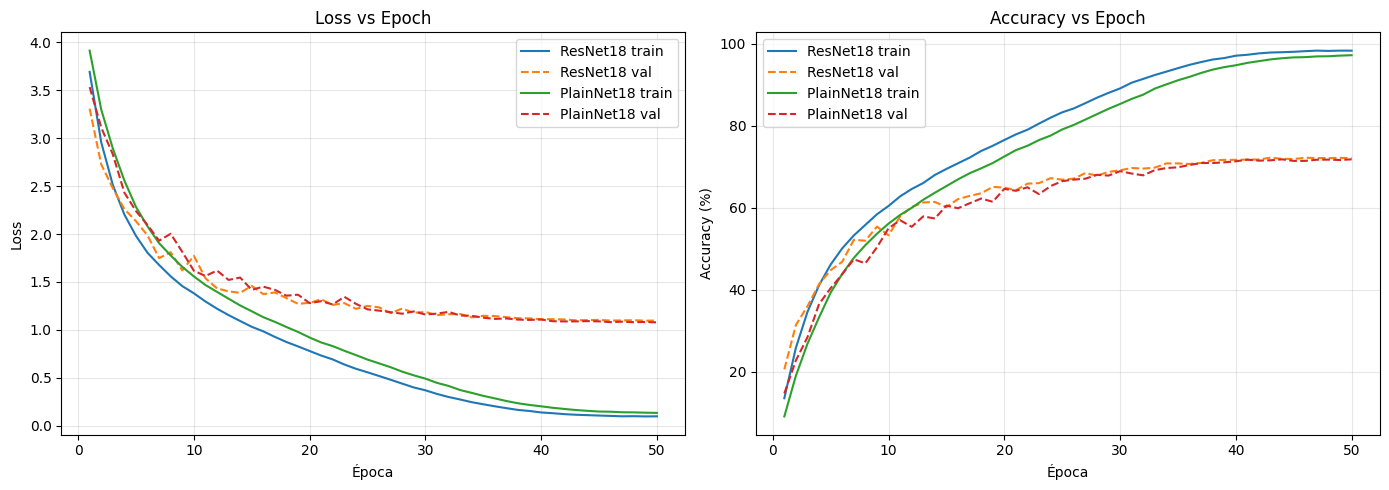

In [14]:
# Curvas de entrenamiento

epochs = range(1, num_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(epochs, history_resnet['train_loss'], label='ResNet18 train')
axes[0].plot(epochs, history_resnet['val_loss'],   label='ResNet18 val', linestyle='--')
axes[0].plot(epochs, history_plain['train_loss'],  label='PlainNet18 train')
axes[0].plot(epochs, history_plain['val_loss'],    label='PlainNet18 val', linestyle='--')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss vs Epoch')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs, history_resnet['train_acc'], label='ResNet18 train')
axes[1].plot(epochs, history_resnet['val_acc'],   label='ResNet18 val', linestyle='--')
axes[1].plot(epochs, history_plain['train_acc'],  label='PlainNet18 train')
axes[1].plot(epochs, history_plain['val_acc'],    label='PlainNet18 val', linestyle='--')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy vs Epoch')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [15]:
def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)


print('=' * 60)
print(f'Parámetros ResNet18:    {count_params(model_resnet):,}')
print(f'Parámetros PlainNet18:  {count_params(model_plain):,}')
print()
print(f'Accuracy final val ResNet18:   {history_resnet["val_acc"][-1]:.2f}%')
print(f'Accuracy final val PlainNet18: {history_plain["val_acc"][-1]:.2f}%')
print()
print(f'Mejor accuracy val ResNet18:   {max(history_resnet["val_acc"]):.2f}%')
print(f'Mejor accuracy val PlainNet18: {max(history_plain["val_acc"]):.2f}%')

Parámetros ResNet18:    11,220,132
Parámetros PlainNet18:  11,046,308

Accuracy final val ResNet18:   72.13%
Accuracy final val PlainNet18: 71.85%

Mejor accuracy val ResNet18:   72.27%
Mejor accuracy val PlainNet18: 71.85%
